In [6]:
from pathlib import Path
import requests

In [ ]:
prot_loc = "https://raw.githubusercontent.com/OpenFreeEnergy/ExampleNotebooks/refs/heads/main/rbfe_tutorial/tyk2_protein.pdb"
lig_loc = "https://raw.githubusercontent.com/OpenFreeEnergy/ExampleNotebooks/refs/heads/main/rbfe_tutorial/tyk2_ligands.sdf"

In [ ]:
prot_str = requests.get(prot_loc).text
lig_str = requests.get(ligand_loc).text

In [ ]:
from rdkit import Chem
from rdkit.Chem import AllChem
from rdkit.Chem import Draw

# Extract the contents of the sdf file and visualise it
Path('inputs').mkdir(parents=True, exist_ok=True)
Path('inputs/tyk2_ligands.sdf').write_text(lig_str)
ligands_rdmol = [mol for mol in
                 Chem.SDMolSupplier('inputs/tyk2_ligands.sdf', removeHs=False)]

for ligand in ligands_rdmol:
    AllChem.Compute2DCoords(ligand)

Chem.Draw.MolsToGridImage(ligands_rdmol)

In [ ]:
from openfe import SmallMoleculeComponent

# Load ligands using RDKit
ligands_sdf = Chem.SDMolSupplier('inputs/tyk2_ligands.sdf', removeHs=False)

# Now pass these to form a list of Molecules
ligand_mols = [SmallMoleculeComponent(sdf) for sdf in ligands_sdf]

Matplotlib is building the font cache; this may take a moment.


In [18]:
from openff.toolkit import Molecule
from openfe import SmallMoleculeComponent

# Load ligands using OpenFF toolkit
ligands_sdf = Molecule.from_file('inputs/tyk2_ligands.sdf')

# Now pass these to form a list of Molecules
ligand_mols = [SmallMoleculeComponent.from_openff(sdf) for sdf in ligands_sdf]

In [19]:
from openfe.setup import LomapAtomMapper
mapper = LomapAtomMapper()
lomap_mapping = next(mapper.suggest_mappings(ligand_mols[0], ligand_mols[4]))

In [20]:
from kartograf import KartografAtomMapper
# Build Kartograf Atom Mapper
mapper = KartografAtomMapper(atom_map_hydrogens=True)

# Get Mapping
kartograf_mapping = next(mapper.suggest_mappings(ligand_mols[0], ligand_mols[4]))

INFO:	#################################
INFO:	Map Heavy Atoms 
INFO:	#################################
INFO:	Masking Atoms
INFO:	Build Distance Matrix
INFO:	Calculate Mapping
INFO:	Find Maximal overlapping connected sets of mapped atoms
INFO:	#################################
INFO:	Map Hydrogen Atoms: 
INFO:	#################################
INFO:	Masking Atoms
INFO:	Build Distance Matrix
INFO:	Calculate Mapping
INFO:	Find Maximal overlapping connected sets of mapped atoms
INFO:	Filtering bond breaks


In [ ]:
# Create network from the two molecules
import openfe
from openfe.setup.ligand_network_planning import generate_radial_network
from openfe.setup.ligand_network_planning import generate_minimal_spanning_network
from openfe.setup.ligand_network_planning import generate_lomap_network
from openfe.setup import LomapAtomMapper

# Create an MST network
mst_network = generate_minimal_spanning_network(
    ligands=ligand_mols,
    scorer=openfe.lomap_scorers.default_lomap_score,
    mappers=[LomapAtomMapper(),])

# Create a LOMAP network
lomap_network = generate_lomap_network(
    molecules=ligand_mols,
    scorer=openfe.lomap_scorers.default_lomap_score,
    mappers=[LomapAtomMapper(),])

# Create a radial, choosing the first ligand as central ligand
radial_network = generate_radial_network(
    ligands=ligand_mols[1:],
    central_ligand=ligand_mols[0],
    mappers=[LomapAtomMapper(),])

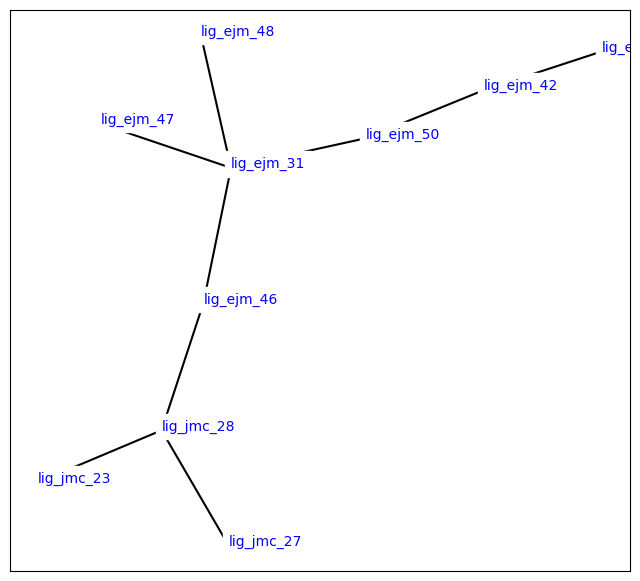

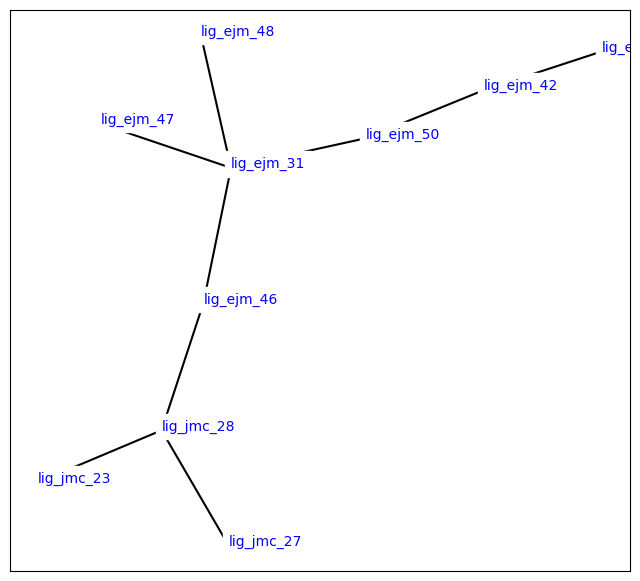

In [22]:
from openfe.utils.atommapping_network_plotting import plot_atommapping_network

plot_atommapping_network(mst_network)

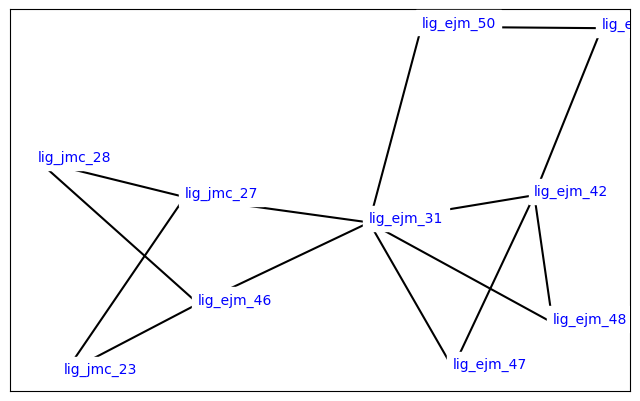

In [23]:
# Visualize the LOMAP network
from openfe.utils.atommapping_network_plotting import plot_atommapping_network

plot_atommapping_network(lomap_network)

In [24]:
# Convert to graphml
with open("network_store.graphml", "w") as writer:
    writer.write(mst_network.to_graphml())

In [25]:
from openfe import SolventComponent, ProteinComponent
from openff.units import unit
Path('inputs/tyk2_protein.pdb').write_text(prot_str)
protein = ProteinComponent.from_pdb_file('inputs/tyk2_protein.pdb')

# Note: the distance from the solute to add water is not defined here but in the
# the relevant RBFE solver method
solvent = SolventComponent(positive_ion='Na', negative_ion='Cl',
                           neutralize=True, ion_concentration=0.15*unit.molar)

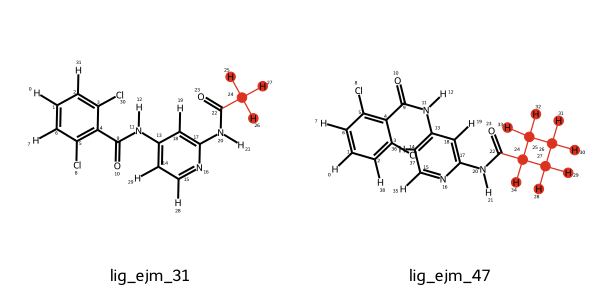

In [26]:
ejm_31_to_ejm_47 = [edge for edge in mst_network.edges if edge.componentB.name == "lig_ejm_47"][0]

ejm_31_to_ejm_47

In [27]:
# Let's create the four ChemicalSystems
from openfe import ChemicalSystem

ejm_31_complex = ChemicalSystem({'ligand': ejm_31_to_ejm_47.componentA,
                                  'solvent': solvent,
                                  'protein': protein,},
                               name=ejm_31_to_ejm_47.componentA.name)
ejm_31_solvent = ChemicalSystem({'ligand': ejm_31_to_ejm_47.componentA,
                                  'solvent': solvent,},
                               name=ejm_31_to_ejm_47.componentA.name)

ejm_47_complex = ChemicalSystem({'ligand': ejm_31_to_ejm_47.componentB,
                                 'solvent': solvent,
                                 'protein': protein,},
                               name=ejm_31_to_ejm_47.componentB.name)
ejm_47_solvent = ChemicalSystem({'ligand': ejm_31_to_ejm_47.componentB,
                                 'solvent': solvent,},
                               name=ejm_31_to_ejm_47.componentB.name)

In [29]:
from openfe.protocols.openmm_rfe import RelativeHybridTopologyProtocol
from openff.units import unit

# Create the default settings
rbfe_settings = RelativeHybridTopologyProtocol.default_settings()

rbfe_settings.simulation_settings.equilibration_length = 10 * unit.picosecond # Reduce equilibration length to 10 picoseconds
rbfe_settings.simulation_settings.production_length = 50 * unit.picosecond # Reduce prodution length to 50 picoseconds

rbfe_settings.simulation_settings
# Create RBFE Protocol class
rbfe_protocol = RelativeHybridTopologyProtocol(
    settings=rbfe_settings
)

In [30]:
transformation_complex = openfe.Transformation(
            stateA=ejm_31_complex,
            stateB=ejm_47_complex,
            mapping=ejm_31_to_ejm_47,
            protocol=rbfe_protocol,  # use protocol created above
            name=f"{ejm_31_complex.name}_{ejm_47_complex.name}_complex"
        )
transformation_solvent = openfe.Transformation(
            stateA=ejm_31_solvent,
            stateB=ejm_47_solvent,
            mapping=ejm_31_to_ejm_47,
            protocol=rbfe_protocol,  # use protocol created above
            name=f"{ejm_31_solvent.name}_{ejm_47_solvent.name}_solvent"
        )

In [31]:
complex_dag = transformation_complex.create()

solvent_dag = transformation_solvent.create()

In [ ]:
# complex dry-run
complex_unit = list(complex_dag.protocol_units)[0]
complex_unit.run(dry=True, verbose=True)

In [ ]:
# solvent dry-run
solvent_unit = list(solvent_dag.protocol_units)[0]
solvent_unit.run(dry=True, verbose=True)

In [36]:
transformation_dir = Path("tyk2_json")
transformation_dir.mkdir(exist_ok=True)

# then we write out the transformations
transformation_complex.dump(transformation_dir / f"{transformation_complex.name}.json")
transformation_solvent.dump(transformation_dir / f"{transformation_solvent.name}.json")

/Users/conor/mamba/envs/openfe_tyk2_vast/lib/python3.10/site-packages/gufe/transformations/transformation.py:124: DeprecationWarning: use of this method is deprecated; instead use `to_json`
  warnings.warn(
/Users/conor/mamba/envs/openfe_tyk2_vast/lib/python3.10/site-packages/gufe/transformations/transformation.py:124: DeprecationWarning: use of this method is deprecated; instead use `to_json`
  warnings.warn(
